In [11]:
import sys
import os
import matplotlib.pyplot as plt
import networkx as nx
import pickle

# Add the parent directory to the path to import from src
sys.path.append(os.path.abspath(".."))
from concept_creator.critical_point_concept_service import (
    CriticalPointConceptService,
)

# Configuration
uri = "bolt://localhost:7687"
user = "neo4j"
password = "111122223333"
session_id = "1_2"
concept_name = session_id



In [12]:
# Create the concept with visualization
service = CriticalPointConceptService(uri, user, password)
concept_id, concept_graph = service.create_concept_incrementally(
    session_id, concept_name
)

INFO:root:Initializing ConceptCreationRepository
INFO:root:Database connection established
INFO:concept_creator.critical_point_concept_service:CriticalPointConceptService initialized.
INFO:concept_creator.critical_point_concept_service:Creating concept for session 1_2 using Critical Point approach.
INFO:root:Getting image IDs for session 1_2
INFO:concept_creator.critical_point_concept_service:Initialized concept with graph from image 5d26db72-6973-4012-b289-b0e377fb924e. Nodes: 15
INFO:concept_creator.critical_point_concept_service:Processing image 2/2: 92472205-9483-4605-8824-b7a43da0b020
INFO:concept_creator.critical_point_concept_service:Updated concept after image 92472205-9483-4605-8824-b7a43da0b020. Nodes: 14


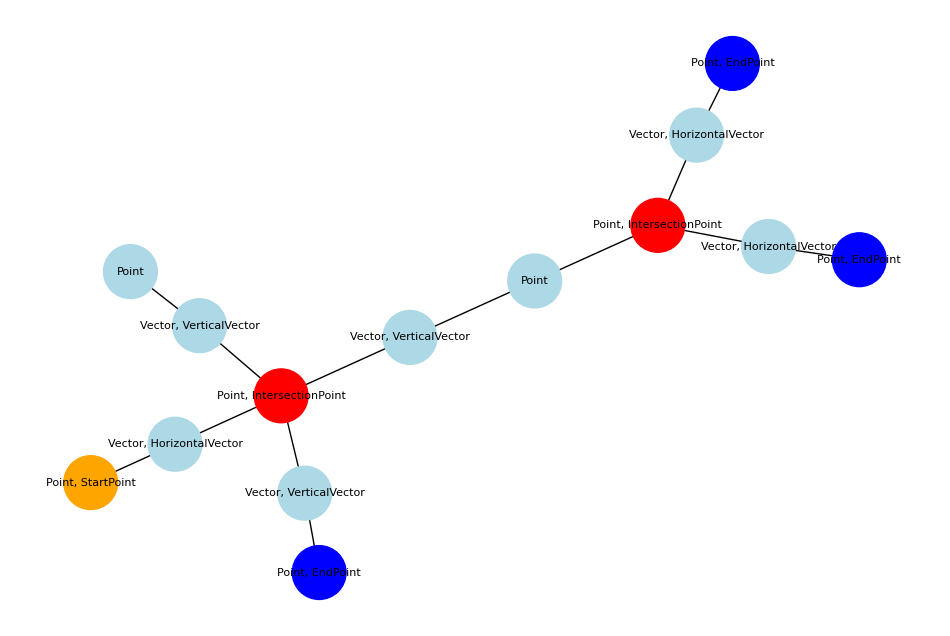

In [13]:
# Create a new figure
plt.figure(figsize=(12, 8))

node_to_color = {
    "IntersectionPoint": "red",
    "CornerPoint": "green",
    "EndPoint": "blue",
    "QuadrantChangePoint": "purple",
    "StartPoint": "orange"
}

# Get node colors based on node labels
node_colors = []
labels_for_nodes = {}

for node in concept_graph.nodes():
    # Get labels from node attributes - try different ways to access labels
    node_data = concept_graph.nodes[node]
    
    # First, try to get labels as a direct attribute
    labels = node_data.get('labels', [])
    
    # If labels is empty, try to get them from node_labels attribute
    if not labels and 'node_labels' in node_data:
        labels = node_data['node_labels']
    
    # If still empty, check if any attribute has 'label' in its name
    if not labels:
        for key in node_data:
            if 'label' in key.lower() and node_data[key]:
                if isinstance(node_data[key], list):
                    labels = node_data[key]
                else:
                    labels = [str(node_data[key])]
                break
    
    # If everything fails, use a default label
    if not labels:
        labels = ["Point"]
    
    # Store labels for node labeling
    labels_for_nodes[node] = ', '.join(str(label) for label in labels) if labels else str(node)
    
    # Check if any label matches our color mapping
    color = 'lightblue'  # Default color
    for label in labels:
        label_str = str(label)  # Convert to string if it's not already
        if label_str in node_to_color:
            color = node_to_color[label_str]
            break
    
    node_colors.append(color)

# Draw the graph with explicit node_color parameter
pos = nx.spring_layout(concept_graph)  # Calculate positions
nx.draw_networkx_nodes(concept_graph, pos, node_color=node_colors, node_size=1500)
nx.draw_networkx_edges(concept_graph, pos)
nx.draw_networkx_labels(concept_graph, pos, labels=labels_for_nodes, font_size=8)
plt.axis('off')
plt.show()

In [14]:
# Printing the graph properties per node
for node in concept_graph.nodes():
    print(f"Node {node}: {concept_graph.nodes[node]}")

Node 4:95f7de00-19a5-43d7-b929-cea0efad5c70:18674: {'labels': ['Point', 'StartPoint'], 'intersection_points_count': 2, 'cycle_count': 0, 'corner_points_count': 2, 'normalized_x': {'min': -0.4, 'max': -0.2, 'type': 'range', 'center': -0.30000000000000004}, 'y': {'min': 66.43668122270572, 'max': 75.59825327510939, 'type': 'range', 'center': 71.01746724890755}, 'vectors_count': {'min': 5, 'max': 7, 'type': 'range', 'center': 6.0}, 'contour_type': 'OPEN', 'relative_distance': {'min': 0.2, 'max': 0.4, 'type': 'range', 'center': 0.30000000000000004}, 'session_id': '1_2', 'normalized_y': {'min': -0.3, 'max': -0.2, 'type': 'range', 'center': -0.25}, 'quadrant_change_count': {'min': 2, 'max': 4, 'type': 'range', 'center': 3.0}, 'endpoints_count': 3, 'x': {'min': 62.47161572052949, 'max': 81.56331877729338, 'type': 'range', 'center': 72.01746724891143}, 'monotony': 'NON_MONOTONIC'}
Node 4:95f7de00-19a5-43d7-b929-cea0efad5c70:18681: {'labels': ['Vector', 'HorizontalVector'], 'x1': {'min': 75.5994